# 9 Data Transformation
### DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING
By **Mohan Sirumalla**
***


## Objective:

This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.

### Dataset:

Given “Adult” dataset, which predicts whether income exceeds $50K/yr based on census data.

In [64]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [65]:
# Load and Read Data set
df = pd.read_csv("adult_with_headers.csv",skipinitialspace=True) # skipinitialspace=True remove leading spaces
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [66]:
df[['education','education_num']]

,education,education_num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
...,...,...
32556,Assoc-acdm,12
32557,HS-grad,9
32558,HS-grad,9
32559,HS-grad,9


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [68]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [69]:
# numeric columns
numeric_cols = df.select_dtypes(include=np.number)
# non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=np.number)

In [70]:
for col in non_numeric_cols.columns:
    print(f"{col}: {non_numeric_cols[col].unique()}")

workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital_status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex: ['Male' 'Female']
native_country: ['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' '

In [71]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Tasks:

### 1. Handle missing values as per the best practices (imputation, removal, etc.)


There are no null values in the dataset\
Although the dataset does not contain any null values, a closer look  tells us that there are a lot of '?' values in our dataset.\
We will have to replace those values!

In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [73]:
df[['education','education_num']]

,education,education_num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
...,...,...
32556,Assoc-acdm,12
32557,HS-grad,9
32558,HS-grad,9
32559,HS-grad,9


In [74]:
for col in numeric_cols:
    print(f"{col} having Minimum value {df[col].min()} and  Maxmium value {df[col].max()}  and average {df[col].mean()}")


age having Minimum value 17 and  Maxmium value 90  and average 38.58164675532078
fnlwgt having Minimum value 12285 and  Maxmium value 1484705  and average 189778.36651208502
education_num having Minimum value 1 and  Maxmium value 16  and average 10.0806793403151
capital_gain having Minimum value 0 and  Maxmium value 99999  and average 1077.6488437087312
capital_loss having Minimum value 0 and  Maxmium value 4356  and average 87.303829734959
hours_per_week having Minimum value 1 and  Maxmium value 99  and average 40.437455852092995


In [75]:
# replace all ? with null nan
df[df == '?'] = np.nan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [76]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [77]:
# replace null with Mode
for col in ['workclass', 'occupation', 'native_country']:
    mode_val = df[col].mode()[0]
    df.fillna({col: mode_val}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [78]:
df[['education','education_num']]

,education,education_num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
...,...,...
32556,Assoc-acdm,12
32557,HS-grad,9
32558,HS-grad,9
32559,HS-grad,9


#### - Apply scaling techniques to numerical features:
1. Standard Scaling\
   Standard Scaling (or Z-score standardization) transforms data to have a mean of 0 and a standard deviation of 1.\
   It is useful for algorithms that assume normally distributed data or rely on distance metrics
2. Min-Max Scaling\
   Min-Max Scaling (normalization) rescales features to a range, typically 0 to 1, which is useful when features have different scales

In [79]:
from sklearn.preprocessing import StandardScaler
df_ss = df.copy() ## copy of original dataset
numeric_cols_names_ss = df_ss.select_dtypes(include=[np.number]).columns
# Scaling
scaler = StandardScaler()
df_ss[numeric_cols_names_ss] = scaler.fit_transform(df_ss[numeric_cols_names_ss])
df_ss.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,-2.705915e-17,1.000015,-1.582206,-0.775768,-0.115955,0.690484,3.769612
fnlwgt,32561.0,-1.001625e-16,1.000015,-1.681631,-0.681691,-0.108219,0.447877,12.268563
education_num,32561.0,1.471887e-16,1.000015,-3.529656,-0.420060,-0.031360,0.746039,2.300838
capital_gain,32561.0,1.309314e-17,1.000015,-0.145920,-0.145920,-0.145920,-0.145920,13.394578
capital_loss,32561.0,1.016900e-16,1.000015,-0.216660,-0.216660,-0.216660,-0.216660,10.593507
hours_per_week,32561.0,-1.549355e-17,1.000015,-3.194030,-0.035429,-0.035429,0.369519,4.742967


In [17]:
df[['education','education_num']]

,education,education_num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
...,...,...
32556,Assoc-acdm,12
32557,HS-grad,9
32558,HS-grad,9
32559,HS-grad,9


In [18]:
from sklearn.preprocessing import MinMaxScaler
df_mm = df.copy() ## copy of original dataset
numeric_cols_names_mm = df_mm.select_dtypes(include=[np.number]).columns
numeric_cols_names_mm
# Scaling
scaler_mm = StandardScaler()
df_mm[numeric_cols_names_mm] = scaler_mm.fit_transform(df_mm[numeric_cols_names_mm])
df_mm.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,-2.705915e-17,1.000015,-1.582206,-0.775768,-0.115955,0.690484,3.769612
fnlwgt,32561.0,-1.001625e-16,1.000015,-1.681631,-0.681691,-0.108219,0.447877,12.268563
education_num,32561.0,1.471887e-16,1.000015,-3.529656,-0.420060,-0.031360,0.746039,2.300838
capital_gain,32561.0,1.309314e-17,1.000015,-0.145920,-0.145920,-0.145920,-0.145920,13.394578
capital_loss,32561.0,1.016900e-16,1.000015,-0.216660,-0.216660,-0.216660,-0.216660,10.593507
hours_per_week,32561.0,-1.549355e-17,1.000015,-3.194030,-0.035429,-0.035429,0.369519,4.742967


In [19]:
df[['education','education_num']]
df.groupby('education')['education_num'].max().sort_values()

education
Preschool        1
1st-4th          2
5th-6th          3
7th-8th          4
9th              5
10th             6
11th             7
12th             8
HS-grad          9
Some-college    10
Assoc-voc       11
Assoc-acdm      12
Bachelors       13
Masters         14
Prof-school     15
Doctorate       16
Name: education_num, dtype: int64

#### - Discuss the scenarios where each scaling technique is preferred and why.

1. Standardization (StandardScaler)\
Standardization centers data around a mean of 0 with a standard deviation of 1, resulting in a distribution with unit variance. 
   *  **Preferred Scenarios:**
        * Data follows a normal/Gaussian distribution: It works best when the underlying data is normally distributed.
        * Algorithms that assume normally distributed data: Ideal for Linear Regression, Logistic Regression, and Linear Discriminant Analysis (LDA).
        * Principal Component Analysis (PCA): Because PCA aims to maximize variance, it requires features to be centered and scaled equally.\
**Why:** It stabilizes gradient-based optimization, allowing models to converge faster, and handles features with varying units well.

2. Min-Max Scaling (Normalization)
Min-Max Scaling transforms data into a fixed, bounded range, typically [0,1]or[-1,1] 

    * **Preferred Scenarios:**
        * **When data does not follow a Gaussian distribution:** Suitable when the data distribution is unknown or non-normal.
        * **Neural Networks and Image Data:** Used when activation functions (like Sigmoid) or image pixel values (0 - 255)need to be constrained to a specific range.
        * **Distance-Based Algorithms:** Beneficial for KNN or Clustering when you need to preserve the relative relationships between data points.
        * **Sparsity:** Preserves zero values in sparse datasets.
**Why:** It brings all features to the same range without altering the shape of the original distribution (except for scaling), maintaining relative distances.\
**Limitations:** Highly sensitive to outliers; extreme values can squash the rest of the data into a tiny interval.

### 2. Encoding Techniques:

#### Apply One-Hot Encoding to categorical variables with less than 5 categories.
One-hot encoding is a technique to convert categorical variables into a numerical format that machine learning models can use
. It creates a new binary column for each category, where a 1 indicates the presence of that category and 0 indicates its absence.

In [20]:
# check unique values in the Categorical Columns/Variables
for col in non_numeric_cols.columns:
    print(f"{col}: {non_numeric_cols[col].nunique()}")

workclass: 9
education: 16
marital_status: 7
occupation: 15
relationship: 6
race: 5
sex: 2
native_country: 42
income: 2


Only two columns sex and income having than 5 categories.\
and Sex and Income having  only 2 categories, so this is also  **not suitable for** **One Hot Encoding**

One-Hot Encoding >> for Nominal Data\
Label Encoding  >> for Ordinal Data

In [21]:
# Just to demonstrate, i wil be writting the code
# Create a sample DataFrame
data = {'Fruit': ['Apple', 'Banana', 'Mango', 'Banana', 'Apple'],
        'Weight': [150, 120, 200, 130, 160]}
df_extra = pd.DataFrame(data)
print("Original DataFrame:")
print(df_extra)

# Perform one-hot encoding on the 'Fruit' column
df_encoded = pd.get_dummies(df_extra, columns=['Fruit'], dtype=int)
print("\nEncoded DataFrame:")
print(df_encoded)

Original DataFrame:
    Fruit  Weight
0   Apple     150
1  Banana     120
2   Mango     200
3  Banana     130
4   Apple     160

Encoded DataFrame:
   Weight  Fruit_Apple  Fruit_Banana  Fruit_Mango
0     150            1             0            0
1     120            0             1            0
2     200            0             0            1
3     130            0             1            0
4     160            1             0            0


#### Label Encoding for categorical variables. Data Exploration and Preprocessing:
Label encoding converts categorical data into a numerical format, assigning a unique integer to each distinct category.\
This is useful because most machine learning algorithms require numerical input

In [22]:
for col in non_numeric_cols.columns:
    print(f"{col}: {non_numeric_cols[col].unique()}")

workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
marital_status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
sex: ['Male' 'Female']
native_country: ['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' '

In [23]:
df[['education','education_num']]

,education,education_num
0,Bachelors,13
1,Bachelors,13
2,HS-grad,9
3,11th,7
4,Bachelors,13
...,...,...
32556,Assoc-acdm,12
32557,HS-grad,9
32558,HS-grad,9
32559,HS-grad,9


In [24]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [25]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [26]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
df_encode=df.copy()
# 'education',
categorical = ['workclass', 'marital_status', 'occupation', 'relationship',
               'race', 'sex','native_country']
label_encoder = LabelEncoder()
for col in categorical:
    label_encoder.fit(df_encode[col])
    df_encode[col] = label_encoder.transform(df_encode[col])

df_encode.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,Bachelors,13,4,0,1,4,1,2174,0,40,38,<=50K
1,50,5,83311,Bachelors,13,2,3,0,4,1,0,0,13,38,<=50K
2,38,3,215646,HS-grad,9,0,5,1,4,1,0,0,40,38,<=50K
3,53,3,234721,11th,7,2,5,0,2,1,0,0,40,38,<=50K
4,28,3,338409,Bachelors,13,2,9,5,2,0,0,0,40,4,<=50K


In [27]:
df_encode['education'].unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [28]:
df['education'].unique()

array(['Bachelors', 'HS-grad', '11th', 'Masters', '9th', 'Some-college',
       'Assoc-acdm', 'Assoc-voc', '7th-8th', 'Doctorate', 'Prof-school',
       '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], dtype=object)

In [29]:

education_order={'Preschool':1,'1st-4th':2,'5th-6th':3,'7th-8th':4,'9th':5,'10th':6,'11th':7,'12th':8,'HS-grad':9,
                 'Some-college':10,'Assoc-voc':11,'Assoc-acdm':12,'Bachelors':13,'Masters':14,'Prof-school':15,
                 'Doctorate':16}

df_encode['education'] = df_encode['education'].map(education_order)
df_encode['education'] = df_encode['education'].astype(int)
df_encode.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,13,13,4,0,1,4,1,2174,0,40,38,<=50K
1,50,5,83311,13,13,2,3,0,4,1,0,0,13,38,<=50K
2,38,3,215646,9,9,0,5,1,4,1,0,0,40,38,<=50K
3,53,3,234721,7,7,2,5,0,2,1,0,0,40,38,<=50K
4,28,3,338409,13,13,2,9,5,2,0,0,0,40,4,<=50K


#### Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

#### EDA

In [30]:
numeric_cols.columns

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

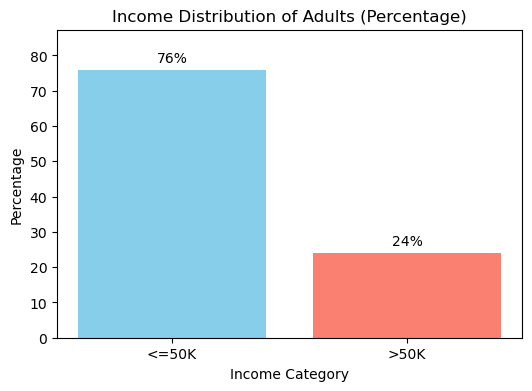

In [31]:
income_counts = df['income'].value_counts(normalize=True).sort_index()*100
plt.figure(figsize=(6, 4)) # Optional: adjust figure size
bars=plt.bar(income_counts.index,income_counts.values,color=['skyblue', 'salmon'])
plt.bar_label(bars, padding=3,fmt='%.0f%%') # to get values of each bar
plt.ylim(0, income_counts.values.max() * 1.15)
plt.title('Income Distribution of Adults (Percentage)')
plt.xlabel('Income Category')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


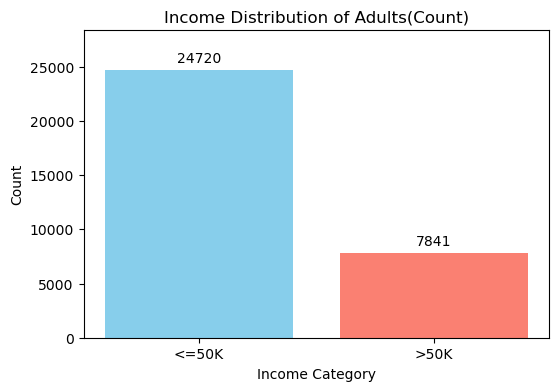

In [32]:
income_counts = df['income'].value_counts()
plt.figure(figsize=(6, 4)) # Optional: adjust figure size
bars=plt.bar(income_counts.index,income_counts.values,color=['skyblue', 'salmon'])
plt.bar_label(bars, padding=3) # to get values of each bar
plt.ylim(0, income_counts.values.max() * 1.15)
plt.title('Income Distribution of Adults(Count)')
plt.xlabel('Income Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [33]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [35]:
# Define the bin edges and labels
bins = [19, 31, 41,51,61,71, np.inf] # np.inf is used for the upper boundary of the last bin
labels = ['19-30', '31-40','41-50','51-60','61-70','Greater Than 70']

# Use pd.cut() to create a new 'AgeGroup' column
# `right=False` means the bins are (min, max], so the right edge is included in the next bin's range.
# For standard [min, max) range, you can omit or set right=True. The example below uses the labels as defined.
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)


In [36]:
df[['age_group','income']]

,age_group,income
0,31-40,<=50K
1,41-50,<=50K
2,31-40,<=50K
3,51-60,<=50K
4,19-30,<=50K
...,...,...
32556,19-30,<=50K
32557,31-40,>50K
32558,51-60,<=50K
32559,19-30,<=50K


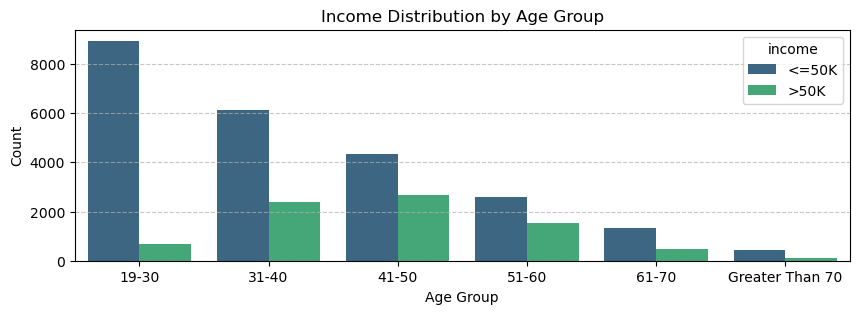

In [41]:
import seaborn as sns

plt.figure(figsize=(10, 3))
sns.countplot(x='age_group', hue='income', data=df, palette='viridis')
plt.title('Income Distribution by Age Group')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

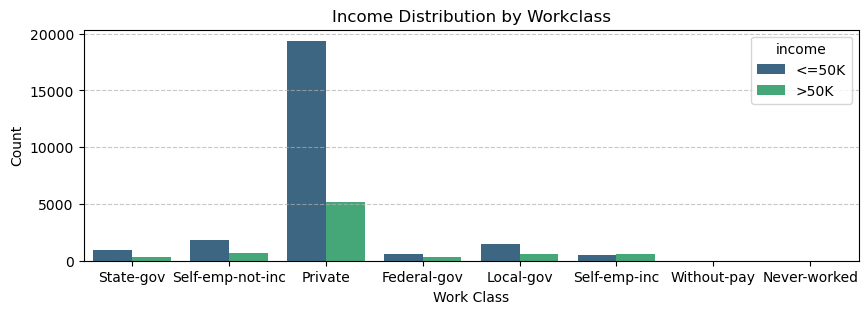

In [42]:
import seaborn as sns

plt.figure(figsize=(10, 3))
sns.countplot(x='workclass', hue='income', data=df, palette='viridis')
plt.title('Income Distribution by Workclass')
plt.ylabel('Count')
plt.xlabel('Work Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### [Handle] variables with more than 5 categories.
Target Encoding

Target Encoding also known as Mean Encoding is a technique where each category in a feature is replaced by the mean of the target variable for that category.

    Useful for high-cardinality features like ZIP codes or product IDs.
    Pros: Captures relationship to target variable.
    Cons: Risk of overfitting, also must apply smoothing/statistical techniques.

In [46]:
!pip install category_encoders

In [48]:
import pandas as pd
import category_encoders as ce

encoder = ce.TargetEncoder(cols=['workclass'])
df_tgt = encoder.fit_transform(df['workclass'], df['income'])

print(f"Encoded Target Data:\n{df_tgt}")

Encoded Target Data:
       workclass
0       0.271957
1       0.284927
2       0.210093
3       0.210093
4       0.210093
...          ...
32556   0.210093
32557   0.210093
32558   0.210093
32559   0.210093
32560   0.557348

[32561 rows x 1 columns]


### Discuss the pros and cons of One-Hot Encoding and Label Encoding.


**One-Hot Encoding**\
One-hot encoding creates new binary columns for each unique category, where a 1 indicates the presence of that category and a 0 indicates its absence. 
**Pros:**
* Avoids implied ordinality: It prevents the model from assuming a non-existent hierarchical order or ranking between categories (e.g., that 'red' is somehow "greater" than 'blue').
* Suitable for nominal data: Ideal for categorical data where the order does not matter (e.g., colors, country names, product categories).
* Improved model performance: Often improves performance in algorithms that expect numerical input and do not handle categorical data directly, such as linear regression, logistic regression, and neural networks.
* Better for distance-based algorithms: Ensures that all categories are equidistant from each other, leading to more meaningful distance calculations in algorithms like k-nearest neighbors (KNN).

**Cons:**
* Increased dimensionality: Creates a new column for every unique category, which can significantly increase the number of features, especially with high-cardinality data (many unique categories).
* Memory intensive and slow training: High dimensionality can lead to increased memory usage and make the model slower to train (the "curse of dimensionality").
* Sparse data: Most observations will have a value of 0 in most of the new columns, resulting in sparse data. 

**Label Encoding**\
Label encoding converts each category into a unique integer value in a single column (e.g., "low" -> 0, "medium" -> 1, "high" -> 2). In Python, scikit-learn's LabelEncoder is typically used for target variables, while OrdinalEncoder (or manual mapping with pandas) is used for input features. 
**Pros:**

* Memory efficient: Does not increase the dimensionality of the dataset, making it more memory-efficient and compact compared to one-hot encoding.
* Suitable for ordinal data: Works well when the categorical data has a natural, meaningful order or ranking (e.g., education levels, clothing sizes).
* Easier for tree-based models: Tree-based models like Decision Trees and Random Forests can handle integer-encoded data effectively and are less likely to misinterpret the numerical values as having an arbitrary magnitude. 

**Cons:**
* Implies ordinal relationships: Introduces an artificial order or ranking among categories, which can mislead models if the data is nominal (without inherent order).
* Biased predictions: Models might assign unintended weight or priority to categories with higher numerical values, leading to biased or inaccurate predictions in models that assume continuous numerical relationships (e.g., linear models).
* Can cause issues with distance metrics: The numerical distances between categories (e.g., the difference between 0 and 1 is the same as between 1 and 2) may not reflect the actual relationships if the data is nominal. 

#### 3. Feature Engineering:

##### Create at least 2 new features that could be beneficail for the model. Explain the rationale behind your choices.

Here are 2 new features that can be engineered:
1. **education_level_category** (Derived from education or education.num)
   * **Description:** Group the existing 16+ education levels into broader, ordinal categories (e.g., "Dropout", "HS-Graduate", "Some-College", "Bachelors", "Masters+", "Doctorate").
   * **Rationale:** The original education feature has too many unique categorical values (many of which have similar, low income proportions). Grouping them reduces cardinality and noise, allowing the model to focus on the significant jump in earning potential that occurs after attaining a bachelor's or graduate degree.
2. household_stability (Derived from marital.status & relationship)
   * **Description:** Create a binary or categorical feature indicating if the individual is in a "Stable" household (e.g., Married-civ-spouse) vs. "Unstable/Individual" (e.g., Never-married, Divorced, Separated, Widowed).
   * Rationale: The marital.status and relationship columns are highly correlated and often redundant. A combined feature captures the economic stability often associated with dual-income households ("Husband/Wife" in relationship and "Married-civ-spouse" in marital.status), which strongly correlates with income over $50k. 

In [54]:
numeric_cols = df.select_dtypes(include=np.number)

In [55]:
numeric_cols.columns

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

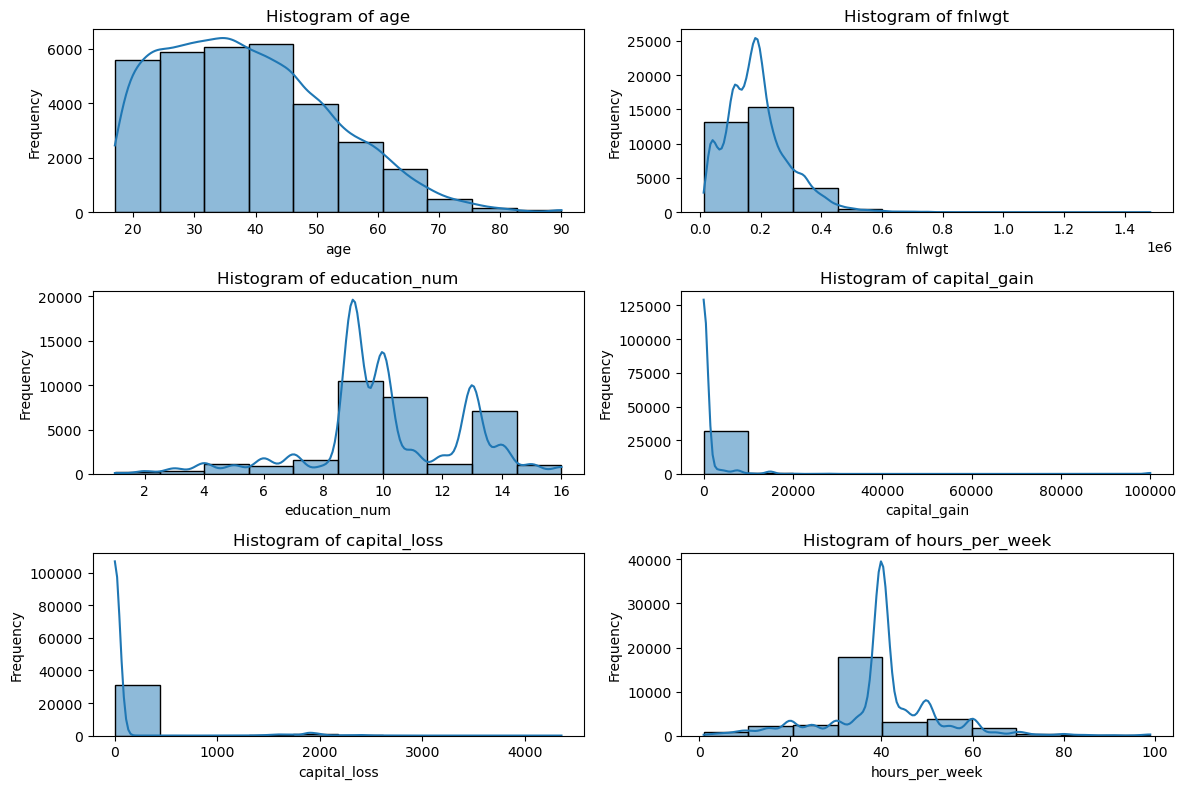

In [57]:
import seaborn as sns
numeric_cols_names=numeric_cols.columns
# histogram
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
for i, col in enumerate(numeric_cols_names):
    plt.subplot(len(numeric_cols_names) // 2 + (len(numeric_cols_names) % 2), 2, i + 1) # Create subplots
    #df[col].hist(bins=10, edgecolor='black') # Plot histogram
    sns.histplot(data=df, x=col, bins=10, kde=True, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

Based on the analysis of the Adult Income Dataset\
The numerical features :capital_gain and capital_loss are highly right-skewed, with most values being zero and a few extremely large values.\
Applying a logarithmic transformation is an effective technique to handle this skewness. 

#### Apply a transfroation (e.g Log transformation) to atleast one skewed numerical feature and justify your choice.

Recommended Transformation: Log Transformation
We will apply log(x + 1) (or np.log1p in Python) to the capital_gain feature.

In [58]:
df['capital_gain'] = np.log1p(df['capital_gain'])
df['capital_loss'] = np.log1p(df['capital_loss'])

In [60]:
df['capital_gain']

0        7.684784
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
32556    0.000000
32557    0.000000
32558    0.000000
32559    0.000000
32560    9.617471
Name: capital_gain, Length: 32561, dtype: float64

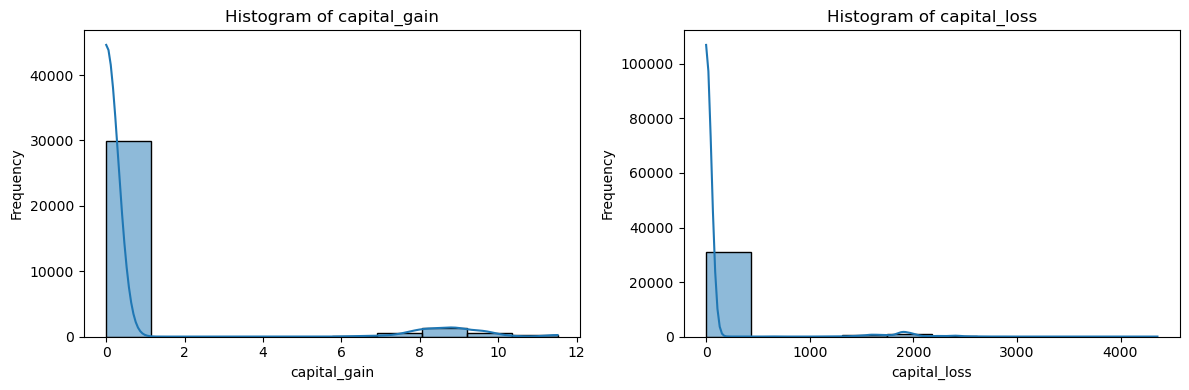

In [63]:
numeric_cols_names=['capital_gain','capital_loss']
# histogram
plt.figure(figsize=(12, 4)) # Adjust figure size as needed
for i, col in enumerate(numeric_cols_names):
    plt.subplot(len(numeric_cols_names) // 2 + (len(numeric_cols_names) % 2), 2, i + 1) # Create subplots
    #df[col].hist(bins=10, edgecolor='black') # Plot histogram
    sns.histplot(data=df, x=col, bins=10, kde=True, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

**Justification**
* **Reduces Right-Skewness:** The capital_gain data is heavily skewed because most people have zero capital gains, while a small percentage have very high gains. The log transformation compresses the upper tail (large values) and stretches out the lower values (zeros/small values), resulting in a distribution that is closer to normal (Gaussian).
* **Handles Zeros:** Since capital_gain contains zeros, a standard log(x) transformation would fail (log(0) is undefined). The log1p(x) formula (log(x + 1)) is used because it transforms 0 to 0 (log(0+1)=log(1)=0), preserving zero-gain data points while normalizing the rest.
* **Improves Model Performance:** Many machine learning algorithms (e.g., Logistic Regression, Linear Regression) assume normally distributed data and perform poorly with heavy tails or outliers. This transformation helps the model make more accurate predictions by reducing the disproportionate influence of extreme values